# Single-influx PDE of a randomly-sampled community

Sample one community from `JansSampler3`, find its non-spatial steady state, perturb it, and integrate the 1D PDE on a periodic domain. Inspect spatial profiles, a kymograph, and the dispersion relation.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import palettable as pal

from scipy import stats as scistats
from scipy.stats import binom as binom_dist

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--', 'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state, solve_pde
from ssmc.params import SpatialMiCRMParams
from ssmc.plotting import plot_dispersion, plot_1d_snapshot

## 1. Build sampler and draw an unstable community

We rejection-sample until we land on a draw whose dispersion relation is Turing-unstable (otherwise the PDE just relaxes to the homogeneous fixed point).

In [41]:
def make_sampler(K, l_influx, Dr_byp=1.0, Ns=10, Nr=10):
    """Single-influx sampler.
    """
    return JansSampler3(
        Ns=Ns, Nr=Nr,
        m=stats.lognorm(s=0.3, scale=1.0),
        r=Dirac(1.0),
        num_influx_resources=1,
        K=Dirac(K),
        prob_eating=0.7, prob_eating_influx=1.0,
        num_byproducts=Dirac(2),
        c=stats.lognorm(s=0.3, scale=1.0),
        l=stats.uniform(loc=0.3, scale=0.5),
        cinflux=stats.lognorm(s=0.3, scale=1.0),
        linflux=Dirac(l_influx),
        Ds=Dirac(1e-6),
        Dr=Dirac(Dr_byp),       # byproduct diffusion
        Drinflux=Dirac(1.0),    # influx-resource diffusion (fast)
    )

def draw_unstable(sampler, rng, max_tries=40, ks=None):
    if ks is None:
        ks = np.linspace(1e-3, 500.0, 2000)
    for attempt in range(max_tries):
        sparams = sampler(rng)
        micrm = sparams.micrm
        Ns = micrm.Ns
        u0 = np.concatenate([0.1 * np.ones(Ns), micrm.K / np.maximum(micrm.r, 1e-6)])
        u_ss, ok = solve_steady_state(micrm, u0, t_max=2e3, rtol=1e-7, atol=1e-9)
        if not ok or np.max(u_ss[:Ns]) < 1e-6:
            continue
        res = scan_k(sparams, u_ss, ks)
        if classify(res) == 'unstable':
            return sparams, u_ss, res, attempt + 1
    return None

rng = np.random.default_rng(1)
sampler = make_sampler(K=10.0, l_influx=0.999, Dr_byp=.1)
out = draw_unstable(sampler, rng)
assert out is not None, "no unstable community found — re-seed or widen the sampler"
sparams, u_ss, dispersion, n_draws = out
print(f"found unstable draw after {n_draws} tries; peak k={dispersion.max_k:.2f}, max Re λ={dispersion.max_mrl:.3g}")

found unstable draw after 1 tries; peak k=9.76, max Re λ=0.0335


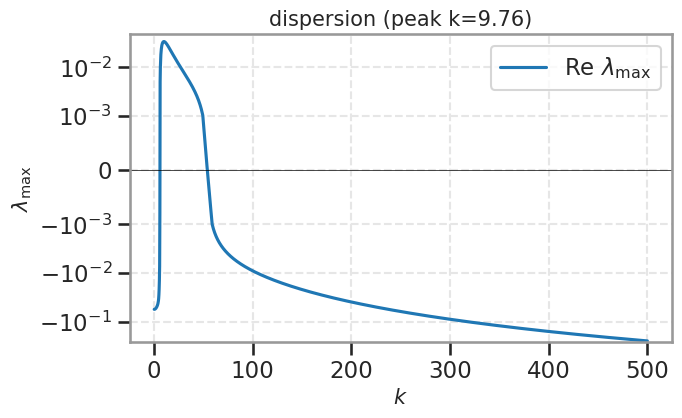

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_dispersion(ax, dispersion.ks, dispersion.mrls)
ax.set_title(f"dispersion (peak k={dispersion.max_k:.2f})")
ax.legend()
plt.yscale("symlog", linthresh=1e-3)
plt.show()

## 2. Build a spatial domain and run the PDE

Pick `dx` so the dominant unstable wavelength `2π/k_*` is well resolved (≥ ~10 grid points per wavelength), and `L_box` so several wavelengths fit.

In [56]:
k_star = dispersion.max_k
L_star = 2 * np.pi / k_star
ssize = 1024
L_box = 16 * L_star
dx = L_box / ssize

# Rebuild sparams with the chosen dx (sampler default was dx=1.0)
sparams_pde = SpatialMiCRMParams(micrm=sparams.micrm, Ds=sparams.Ds, dx=dx, bc="periodic")

ntot = sparams.Ns + sparams.Nr
rng2 = np.random.default_rng(0)
u0 = np.tile(u_ss[:, None], (1, ssize)) * (1.0 + 1e-3 * rng2.standard_normal((ntot, ssize)))

t_max = 20000.0
t_eval = np.linspace(0.0, t_max, 41)
pde = solve_pde(sparams_pde, u0, t_span=(0.0, t_max), t_eval=t_eval, rtol=1e-6, atol=1e-9)
print(f"success={pde.success}, message={pde.message}")
print(f"L_star={L_star:.2f}, L_box={L_box:.2f}, dx={dx:.3f}, ssize={ssize}")

success=True, message=The solver successfully reached the end of the integration interval.
L_star=0.64, L_box=10.30, dx=0.010, ssize=1024


## 3. Final spatial snapshot

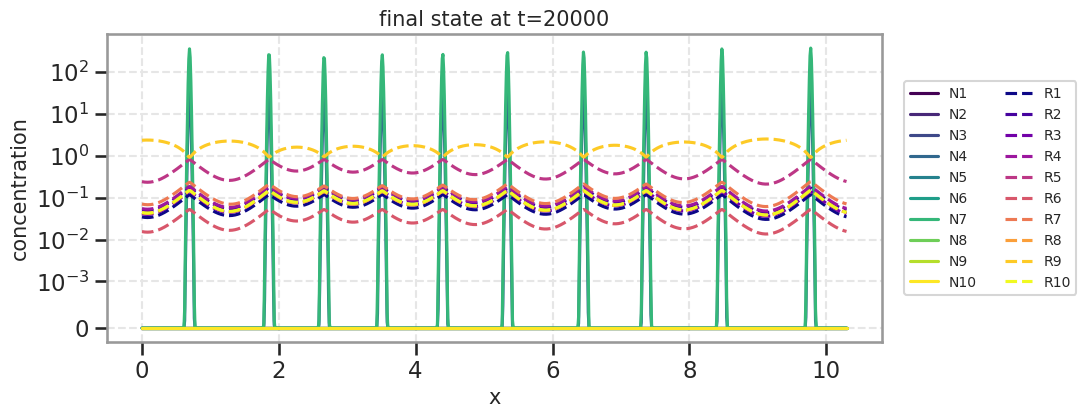

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_1d_snapshot(ax, pde.u[-1], dx, sparams.micrm)
ax.set_title(f"final state at t={pde.t[-1]:.0f}")
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=2, fontsize=10)
plt.yscale("symlog", linthresh=1e-3)
plt.show()

## 4. Kymographs of strain biomass

Time on the y-axis, space on the x-axis, one panel per strain.

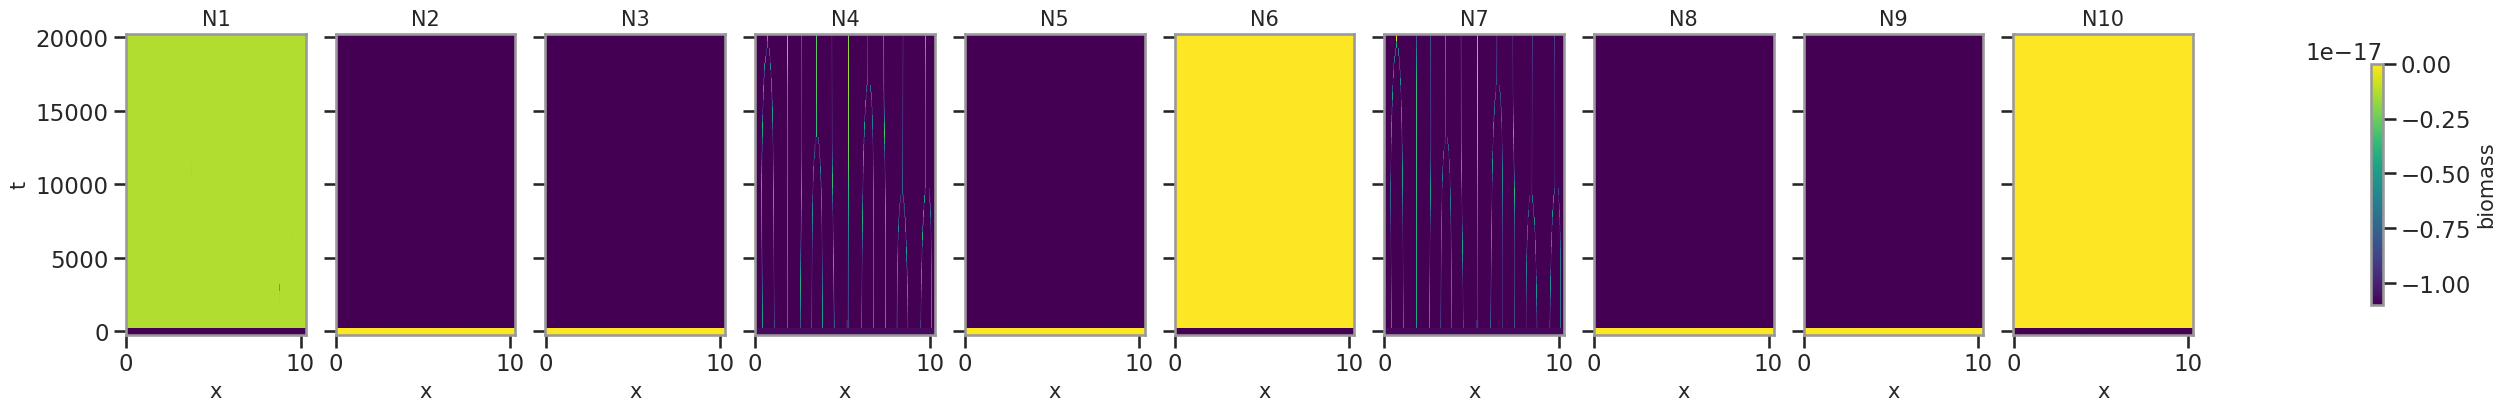

In [58]:
Ns = sparams.Ns
x = np.arange(ssize) * dx
fig, axes = plt.subplots(1, Ns, figsize=(2.5 * Ns, 4), sharey=True, constrained_layout=True)
for i, ax in enumerate(axes):
    im = ax.pcolormesh(x, pde.t, pde.u[:, i, :], cmap='viridis', shading='auto')
    ax.set_title(f"N{i + 1}")
    ax.set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im, ax=axes, shrink=0.8, label='biomass')
plt.show()

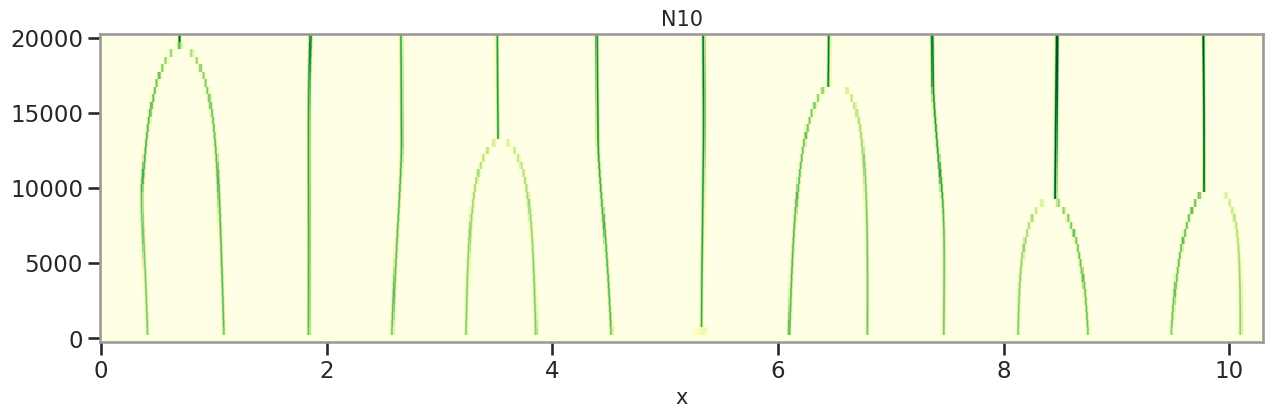

In [62]:
Ns = sparams.Ns
x = np.arange(ssize) * dx
# fig, axes = plt.subplots(1, Ns, figsize=(2.5 * Ns, 4), sharey=True, constrained_layout=True)
biomass = np.zeros((len(t_eval),len(x)))
for i in np.arange(Ns):
    biomass = biomass + pde.u[:, i, :]

fig = plt.figure(figsize=(15, 4))
biomasscmap = pal.colorbrewer.sequential.YlGn_9.mpl_colormap
im = plt.pcolormesh(x, pde.t, biomass, cmap=biomasscmap, shading='auto')
plt.title(f"N{i + 1}")
plt.xlabel('x')
fig.colorbar(im, ax=axes, shrink=0.8, label='biomass')